# Chebyshev Approximation and Minimax Polynomials

Uniform approximation seeks $p_n$ minimizing
$$
\|f-p_n\|_{\infty,[-1,1]}.
$$
Chebyshev interpolation is near-minimax in many practical settings and avoids Runge oscillations.
We compare Taylor and Chebyshev polynomial approximations.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/chebyshev-minimax/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/chebyshev-minimax") if Path("python/chebyshev-minimax").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Chebyshev Approximation and Minimax Polynomials**, with equations and plots designed to expose both the model and the numerical behavior.


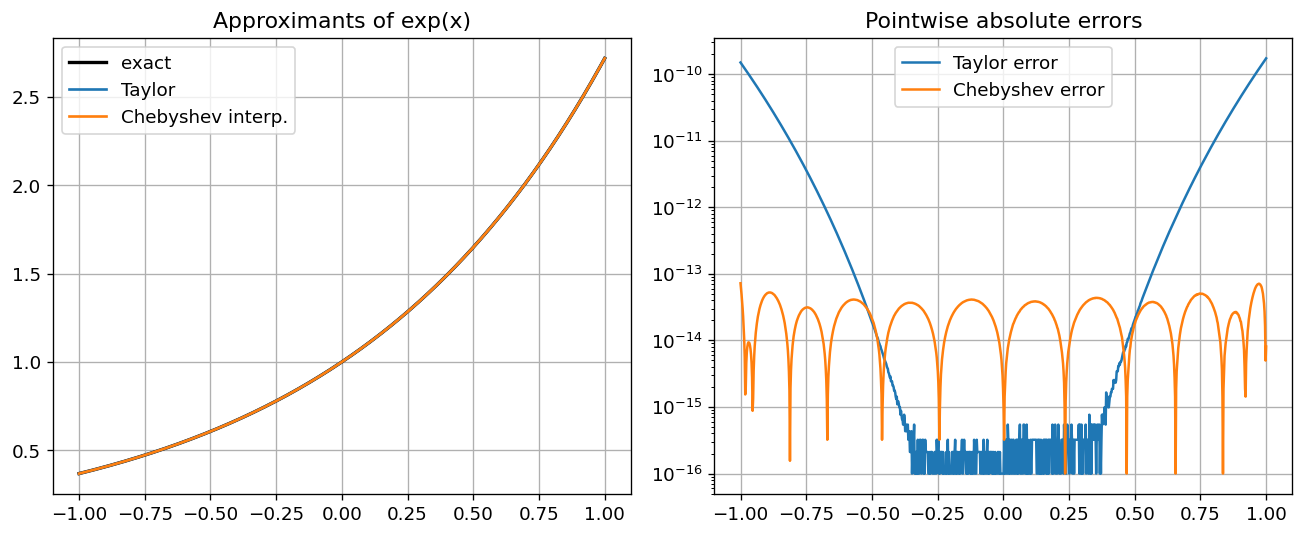

In [2]:
def f(x):
    return np.exp(x)

n = 12
x_dense = np.linspace(-1, 1, 1000)
y_true = f(x_dense)

# Taylor around 0
coef_taylor = np.array([1 / math.factorial(k) for k in range(n + 1)])
V_t = np.vstack([x_dense**k for k in range(n + 1)])
y_taylor = coef_taylor @ V_t

# Chebyshev interpolation nodes
k = np.arange(n + 1)
x_cheb = np.cos((2*k + 1) * np.pi / (2*(n + 1)))
y_cheb = f(x_cheb)
coef_poly = np.polyfit(x_cheb, y_cheb, n)
y_cheb_interp = np.polyval(coef_poly, x_dense)

err_t = np.abs(y_true - y_taylor)
err_c = np.abs(y_true - y_cheb_interp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].plot(x_dense, y_true, "k", lw=2, label="exact")
axes[0].plot(x_dense, y_taylor, lw=1.6, label="Taylor")
axes[0].plot(x_dense, y_cheb_interp, lw=1.6, label="Chebyshev interp.")
axes[0].set_title("Approximants of exp(x)")
axes[0].legend()

axes[1].semilogy(x_dense, err_t + 1e-16, label="Taylor error")
axes[1].semilogy(x_dense, err_c + 1e-16, label="Chebyshev error")
axes[1].set_title("Pointwise absolute errors")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- L. N. Trefethen, *Approximation Theory and Approximation Practice*.
- E. W. Cheney, *Introduction to Approximation Theory*.
